<h3>Display 5 random sample images from the dataset</h3> 


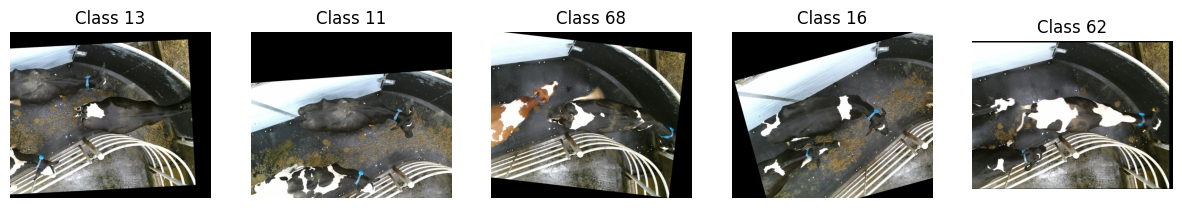

In [2]:
import os

DATA_DIR = "/kaggle/input/hw5-dataset/2yizcfbkuv4352pzc32n54371r"
IMG_EXTENSIONS = (".jpg", ".jpeg", ".png")

class_dirs = [
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
]
def is_image_file(filename):
    return filename.lower().endswith(IMG_EXTENSIONS)
import random
import matplotlib.pyplot as plt
from PIL import Image

sample_classes = random.sample(class_dirs, k=5)

plt.figure(figsize=(15, 6))
idx = 1

for cls in sample_classes:
    cls_path = os.path.join(DATA_DIR, cls)
    images = [f for f in os.listdir(cls_path) if is_image_file(f)]
    
    if len(images) == 0:
        continue
    
    img_path = os.path.join(cls_path, random.choice(images))
    img = Image.open(img_path).convert("RGB")
    
    plt.subplot(1, 5, idx)
    plt.imshow(img)
    plt.title(f"Class {cls}")
    plt.axis("off")
    idx += 1

plt.show()


<h3>Visualize the number of images per class in the dataset</h3>

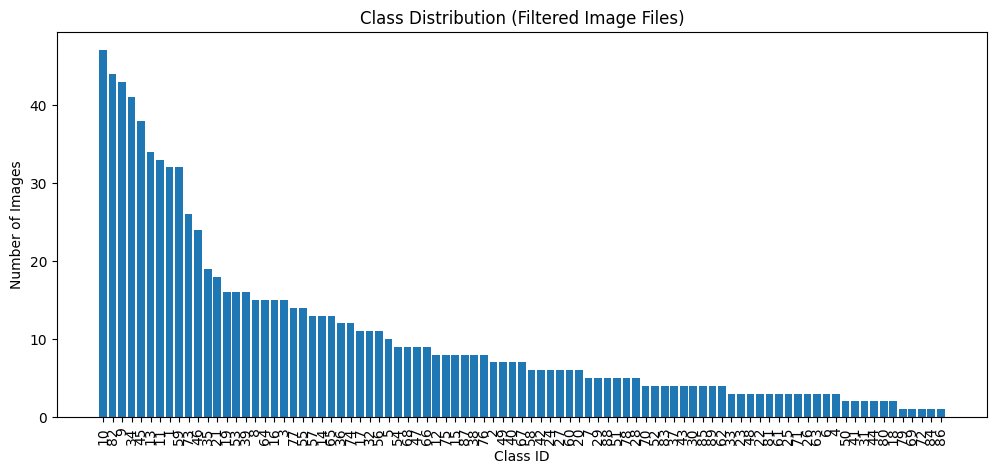

In [14]:
import pandas as pd

class_counts = {}

for cls in class_dirs:
    cls_path = os.path.join(DATA_DIR, cls)
    images = [f for f in os.listdir(cls_path) if is_image_file(f)]
    class_counts[cls] = len(images)

df = pd.DataFrame.from_dict(
    class_counts, orient="index", columns=["num_images"]
).sort_values(by="num_images", ascending=False)
plt.figure(figsize=(12, 5))
plt.bar(df.index, df["num_images"])
plt.xticks(rotation=90)
plt.xlabel("Class ID")
plt.ylabel("Number of Images")
plt.title("Class Distribution (Filtered Image Files)")
plt.show()


<h3>Preprocessing section</h3>

In [15]:
from torchvision import transforms

MIN_SAMPLES = 5

valid_classes = df[df["num_images"] >= MIN_SAMPLES].index.tolist()

print("Number of classes before filtering:", len(df))
print("Number of classes after filtering:", len(valid_classes))

base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])



Number of classes before filtering: 89
Number of classes after filtering: 57


In [ ]:
import os

DATA_DIR = "/kaggle/input/hw5-dataset/2yizcfbkuv4352pzc32n54371r"

data = []  

for cls in valid_classes:
    cls_path = os.path.join(DATA_DIR, cls)
    images = [f for f in os.listdir(cls_path) if is_image_file(f)]
    
    for img in images:
        data.append((os.path.join(cls_path, img), cls))


<h3>Train-test split</h3>

In [17]:
from sklearn.model_selection import train_test_split
from collections import defaultdict

train_data = []
test_data = []

class_to_images = defaultdict(list)

for path, cls in data:
    class_to_images[cls].append(path)

for cls, images in class_to_images.items():
    train_imgs, test_imgs = train_test_split(
        images, test_size=0.2, random_state=42
    )
    
    train_data.extend([(img, cls) for img in train_imgs])
    test_data.extend([(img, cls) for img in test_imgs])


In [8]:
def dataset_stats(dataset):
    classes = set([cls for _, cls in dataset])
    return len(dataset), len(classes)

train_samples, train_classes = dataset_stats(train_data)
test_samples, test_classes = dataset_stats(test_data)

print("Training set:")
print("  Samples:", train_samples)
print("  Classes:", train_classes)

print("\nTest set:")
print("  Samples:", test_samples)
print("  Classes:", test_classes)


Training set:
  Samples: 657
  Classes: 57

Test set:
  Samples: 194
  Classes: 57


<h3>Custom PyTorch Dataset class for Animal ReID with optional transforms and label encoding</h3>

In [14]:
from torch.utils.data import Dataset
from PIL import Image

class AnimalReIDDataset(Dataset):
    def __init__(self, data, transform=None, label_encoder=None):
        self.data = data
        self.transform = transform
        self.label_encoder = label_encoder

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        
        label = self.label_encoder.transform([label])[0]
        return image, label



In [16]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

all_labels = [cls for _, cls in train_data]
label_encoder.fit(all_labels)

num_classes = len(label_encoder.classes_)
print("Number of classes:", num_classes)


Number of classes: 57


<h3>Creating ResNet50 model</h3>

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(pretrained=False)

model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [18]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)


<h3>Creating DataLoader</h3>

In [19]:
train_dataset = AnimalReIDDataset(
    train_data, transform=train_transform, label_encoder=label_encoder
)

test_dataset = AnimalReIDDataset(
    test_data, transform=base_transform, label_encoder=label_encoder
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)


<h3>Training section</h3>

In [ ]:
import os
import torch
from tqdm import tqdm

EPOCHS = 30
SAVE_DIR = "/kaggle/working/checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

train_losses, test_losses = [], []
train_accs, test_accs = [], []

for epoch in range(1, EPOCHS + 1):

    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch} [Train]"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_train_loss = running_loss / len(train_loader)
    train_accuracy = correct / total

    train_losses.append(avg_train_loss)
    train_accs.append(train_accuracy)

    model.eval()
    running_loss = 0.0
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Epoch {epoch} [Test]"):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_test_loss = running_loss / len(test_loader)
    test_accuracy = correct / total

    test_losses.append(avg_test_loss)
    test_accs.append(test_accuracy)

    print(
        f"Epoch {epoch}: "
        f"Train Loss={avg_train_loss:.4f}, Train Acc={train_accuracy:.4f} | "
        f"Test Loss={avg_test_loss:.4f}, Test Acc={test_accuracy:.4f}"
    )

    if epoch % 5 == 0:
        save_path = os.path.join(SAVE_DIR, f"resnet50_epoch_{epoch}.pth")
        torch.save(model.state_dict(), save_path)
        print(f"Model saved at {save_path}")


Epoch 1 [Test]: 100%|██████████| 7/7 [00:02<00:00,  3.03it/s]


Epoch 1: Train Loss=2.7042, Train Acc=0.3166 | Test Loss=2.8859, Test Acc=0.3711


Epoch 2 [Test]: 100%|██████████| 7/7 [00:02<00:00,  2.91it/s]


Epoch 2: Train Loss=2.4870, Train Acc=0.3805 | Test Loss=2.6857, Test Acc=0.4278


Epoch 3 [Test]: 100%|██████████| 7/7 [00:02<00:00,  2.96it/s]


...

Epoch 28: Train Loss=0.2387, Train Acc=0.9467 | Test Loss=0.5628, Test Acc=0.8557


Epoch 29 [Test]: 100%|██████████| 7/7 [00:02<00:00,  2.94it/s]


Epoch 29: Train Loss=0.2437, Train Acc=0.9467 | Test Loss=0.3219, Test Acc=0.9072


Epoch 30 [Test]: 100%|██████████| 7/7 [00:02<00:00,  2.90it/s]


Epoch 30: Train Loss=0.1955, Train Acc=0.9619 | Test Loss=0.3370, Test Acc=0.9124
Model saved at /kaggle/working/checkpoints/resnet50_epoch_30.pth


<h3>Plotting the results</h3>

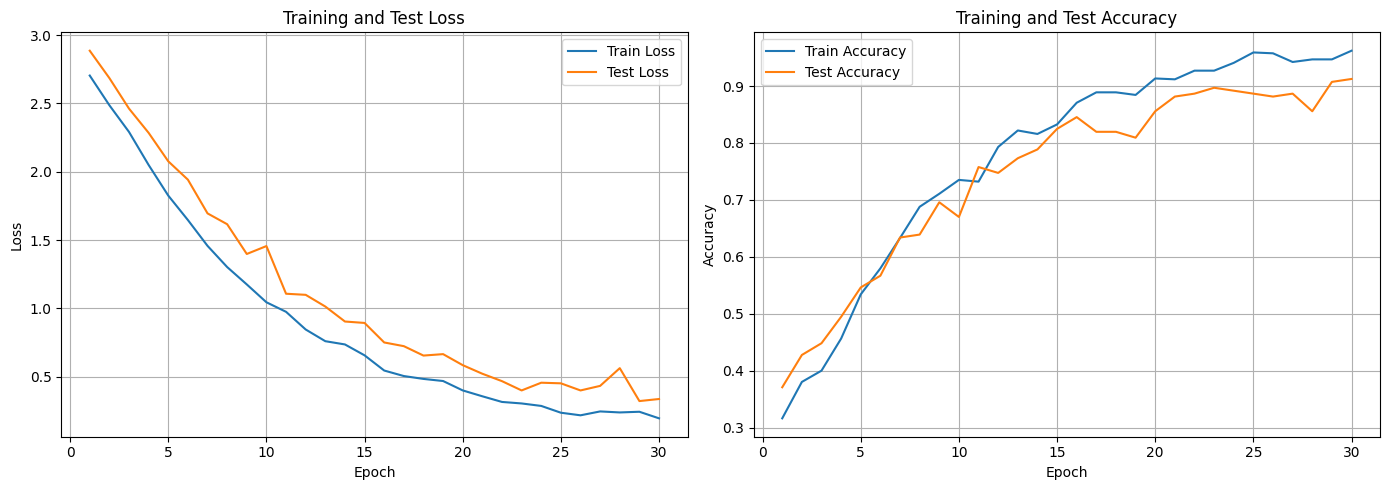

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, label="Train Accuracy")
plt.plot(epochs, test_accs, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


<h3>Creating BotBlock for BotNet50 model</h3>

In [ ]:
import torch
import torch.nn as nn

class BotBlock(nn.Module):

    def __init__(self, in_channels=2048, bottleneck_channels=512, num_heads=8):
        super(BotBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, bottleneck_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(bottleneck_channels)

        self.mhsa = nn.MultiheadAttention(embed_dim=bottleneck_channels, num_heads=num_heads)
        self.bn2 = nn.BatchNorm2d(bottleneck_channels)

        self.conv2 = nn.Conv2d(bottleneck_channels, in_channels, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(in_channels)

        self.relu = nn.ReLU(inplace=True)
        self.attention_output = None  

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        B, C, H, W = out.shape
        seq = out.flatten(2).permute(2, 0, 1) 
        attn_out, _ = self.mhsa(seq, seq, seq)
        self.attention_output = attn_out  

        out = attn_out.permute(1, 2, 0).view(B, C, H, W)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn3(out)

        out += residual
        out = self.relu(out)

        return out


<h3>BotNet50</h3>

In [ ]:
from torchvision import models

class BotNet50(nn.Module):
    def __init__(self, num_classes, bottleneck_channels=512, num_heads=8, pretrained=True):
        super(BotNet50, self).__init__()

        self.backbone = models.resnet50(pretrained=pretrained)

        self.backbone.fc = nn.Identity()
        self.backbone.avgpool = nn.Identity() 

        self.bot_block = BotBlock(
            in_channels=2048,
            bottleneck_channels=bottleneck_channels,
            num_heads=num_heads
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(2048, num_classes)

    def forward(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)

        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        x = self.backbone.layer4(x)

        x = self.bot_block(x)
        attention_features = self.bot_block.attention_output 

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x, attention_features 


In [ ]:
class BotNet50_Summary(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.botnet = BotNet50(num_classes)
    def forward(self, x):
        return self.botnet.backbone(x)  

summary(BotNet50(num_classes=num_classes).to(device), (3,224,224))


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 195MB/s] 


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

<h3>Training section</h3>

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(label_encoder.classes_)

model = BotNet50(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 30
SAVE_DIR = "/kaggle/working/checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

train_losses, test_losses = [], []
train_accs, test_accs = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss, correct, total = 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs, _ = model(images)  
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_losses.append(running_loss/len(train_loader))
    train_accs.append(correct/total)

    model.eval()
    running_loss, correct, total = 0,0,0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs, _ = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    test_losses.append(running_loss/len(test_loader))
    test_accs.append(correct/total)

    print(f"Epoch {epoch}: Train Loss={train_losses[-1]:.4f}, Train Acc={train_accs[-1]:.4f} | "
          f"Test Loss={test_losses[-1]:.4f}, Test Acc={test_accs[-1]:.4f}")

    if epoch % 5 == 0:
        save_path = os.path.join(SAVE_DIR, f"botnet50_epoch_{epoch}.pth")
        torch.save(model.state_dict(), save_path)
        print(f"Model saved at {save_path}")


Epoch 1: Train Loss=2.7770, Train Acc=0.4033 | Test Loss=3.1306, Test Acc=0.5103
Epoch 2: Train Loss=1.2141, Train Acc=0.7458 | Test Loss=1.4839, Test Acc=0.7887
Epoch 3: Train Loss=0.5362, Train Acc=0.9209 | Test Loss=0.6343, Test Acc=0.9330
Epoch 4: Train Loss=0.2422, Train Acc=0.9726 | Test Loss=0.3369, Test Acc=0.9536
Epoch 5: Train Loss=0.1211, Train Acc=0.9878 | Test Loss=0.1924, Test Acc=0.9639
Model saved at /kaggle/working/checkpoints/botnet50_epoch_5.pth
Epoch 6: Train Loss=0.0682, Train Acc=0.9970 | Test Loss=0.1442, Test Acc=0.9691
Epoch 7: Train Loss=0.0437, Train Acc=0.9954 | Test Loss=0.1541, Test Acc=0.9691
Epoch 8: Train Loss=0.0451, Train Acc=0.9939 | Test Loss=0.1190, Test Acc=0.9742
Epoch 9: Train Loss=0.0270, Train Acc=1.0000 | Test Loss=0.1237, Test Acc=0.9691
Epoch 10: Train Loss=0.0275, Train Acc=0.9954 | Test Loss=0.1327, Test Acc=0.9691
Model saved at /kaggle/working/checkpoints/botnet50_epoch_10.pth
Epoch 11: Train Loss=0.0360, Train Acc=0.9954 | Test Loss=0.

<h3>Plotting results</h3>

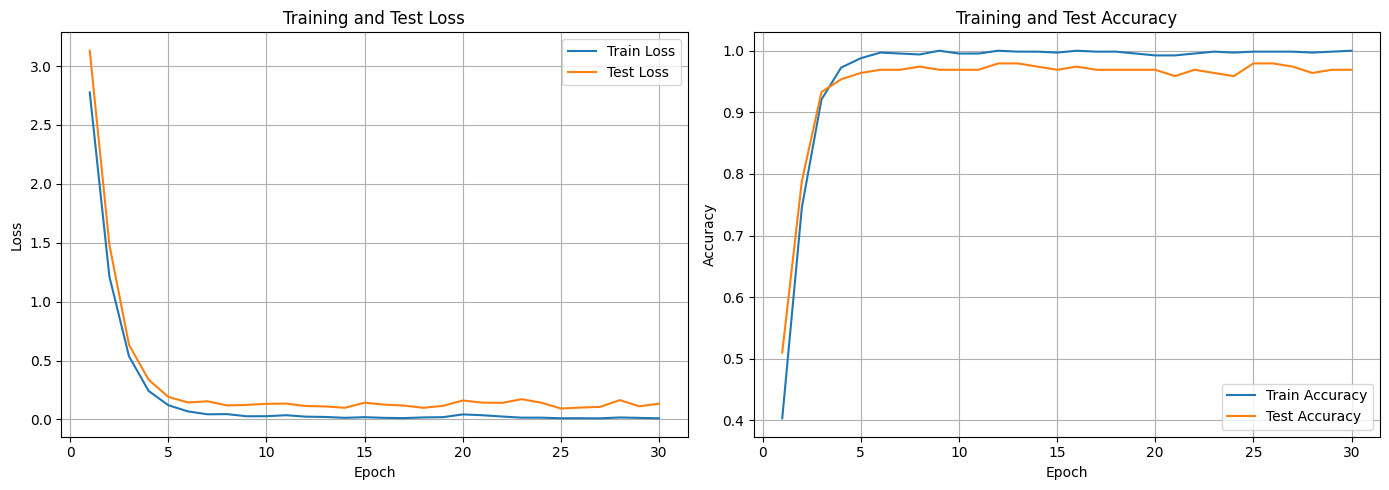

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS+1)
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(epochs, train_accs, label="Train Accuracy")
plt.plot(epochs, test_accs, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [32]:
import shutil

from shutil import copy

copy(
    "/kaggle/working/checkpoints/botnet50_epoch_30.pth",
    "/kaggle/working/botnet50_epoch_30.pth"
)



'/kaggle/working/botnet50_epoch_30.pth'

In [25]:
model = BotNet50(num_classes=57)
model.load_state_dict(torch.load("/kaggle/input/datasets/rezamorid/hw5-models/botnet50_epoch_30.pth"))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


<All keys matched successfully>

<h3>Preprocessing for heatmap

In [ ]:
import torch.nn.functional as F

def get_attention_map(attention_features):
    attn = attention_features.max(dim=1, keepdim=True)[0]  
    attn = F.relu(attn)
    attn -= attn.min(dim=2, keepdim=True)[0].min(dim=3, keepdim=True)[0]
    attn /= attn.max(dim=2, keepdim=True)[0].max(dim=3, keepdim=True)[0] + 1e-8
    return attn



In [37]:
def resize_attention_map(attn_map, target_h, target_w):
    return F.interpolate(attn_map, size=(target_h,target_w), mode='bilinear', align_corners=False)


In [38]:
import matplotlib.pyplot as plt
import numpy as np

def show_heatmap(img_tensor, attn_map):
    img_np = img_tensor.permute(1,2,0).cpu().numpy()
    attn_np = attn_map.squeeze().cpu().numpy()
    plt.figure(figsize=(6,6))
    plt.imshow(img_np)
    plt.imshow(attn_np, cmap='jet', alpha=0.6)
    plt.axis("off")
    plt.show()


In [39]:
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

def unnormalize(img_tensor, mean, std):
    img = img_tensor.clone()
    for t, m, s in zip(img, mean, std):
        t.mul_(s).add_(m)
    return img


<h3>Plotting some heatmaps on original images

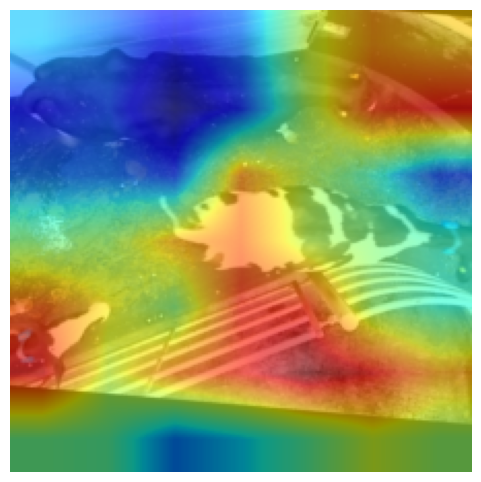

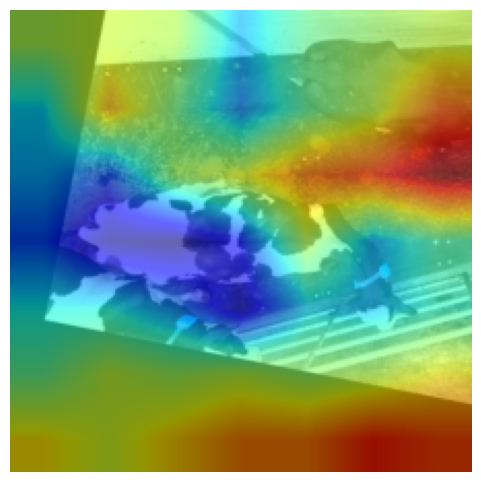

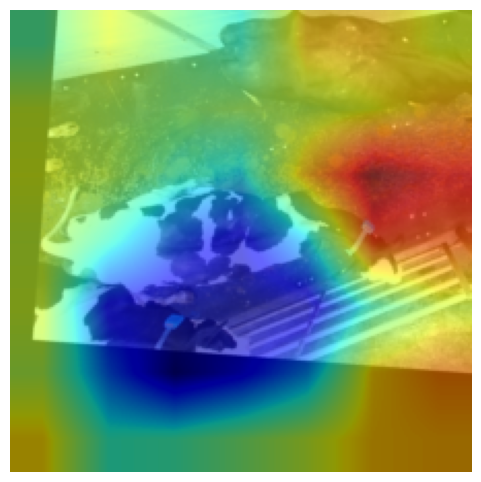

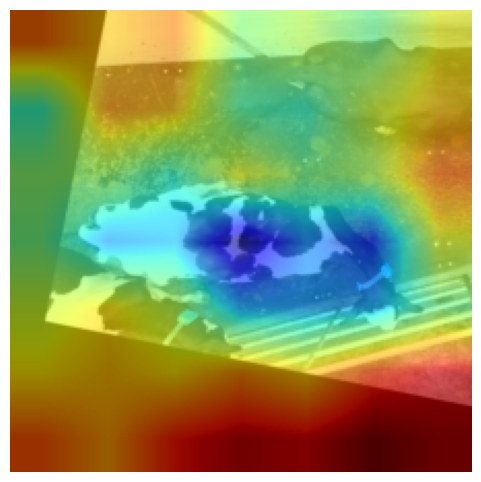

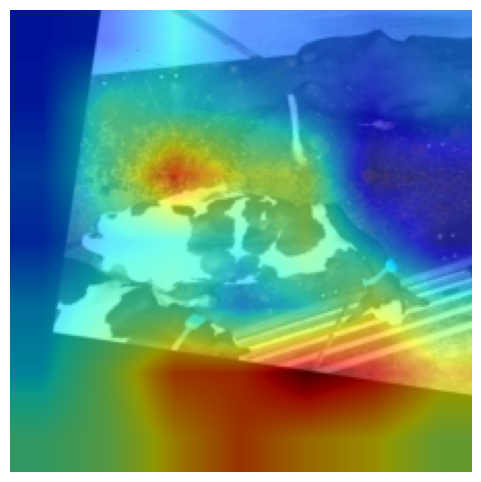

In [42]:
from PIL import Image
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize(224),           
    transforms.CenterCrop(224),       
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])


device = "cpu" if torch.cuda.is_available() else "cpu"
model.eval()

for i in range(5):
    img_path, label = data[i]
    image = Image.open(img_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output, attention_features = model(input_tensor)

    attn_map = get_attention_map(attention_features)
    attn_map = resize_attention_map(attn_map, input_tensor.shape[2], input_tensor.shape[3])
    img_unnorm = unnormalize(input_tensor[0].cpu(), mean, std)
    show_heatmap(img_unnorm, attn_map)
